<a href="https://colab.research.google.com/github/SaimNaveed646/ML_Models/blob/main/Classification/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from dataclasses import dataclass
import numpy as np
import pandas as pd
import plotly.express as px

In [ ]:

from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [ ]:

import pandas as pd

training_df = pd.read_csv("/content/drive/MyDrive/QCRI Project/irisdata.csv")
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  100 non-null    float64
 1   width   100 non-null    float64
 2   Type    100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [ ]:
# training_df = training_df.loc[:, ('length', 'Type')]


In [ ]:
@dataclass
class ExperimentSettings:
    learning_rate: float
    number_epochs: int
    batch_size: int
    input_features: list
    model_name : str
    optimizer: str = "batch"

In [ ]:
class LogisticRegressionModel:
    def __init__(self, n_features, learning_rate, optimizer="batch", batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size

    def sigmoid(self,x):
      return 1/(1+np.exp(-x))

    def predict_proba(self, X):
      linear_pred = np.dot(X, self.weights) + self.bias
      return self.sigmoid(linear_pred)

    def predict(self, X):
      y_pred = self.predict_proba(X)
      return (y_pred >= 0.5).astype(int)





    # # -------------------------
    # # Forward pass
    # # -------------------------
    # def predict(self, X):
    #     # return X @ self.weights + self.bias
    #     linear_pred = np.dot(X, self.weights) + self.bias
    #     y_pred = self.sigmoid(linear_pred)
    #     class_pred = [0 if y<=0.5 else 1 for y in y_pred]
    #     return class_pred

    # -------------------------
    # Gradient computation
    # -------------------------

    def compute_gradients(self, X, y):

        y_pred = self.predict_proba(X)


        error = y_pred - y

        n = len(y)
        dw = (1 / n) * (X.T @ error)
        db = (1 / n) * np.sum(error)

        return dw, db

    # -------------------------
    # Parameter update
    # -------------------------
    def update_parameters(self, dw, db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db

    # -------------------------
    # Loss functions
    # -------------------------
# If it’s smaller than min_value → replace it with min_value

# If it’s larger than max_value → replace it with max_value

# Otherwise → leave it unchanged

    def binary_cross_entropy(self, y, y_pred):
      eps = 1e-15
      y_pred = np.clip(y_pred, eps, 1 - eps)
      return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))



In [ ]:
class LinearRegressionModel:
    def __init__(self, n_features, learning_rate, optimizer="batch", batch_size=32):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.optimizer = optimizer
        self.batch_size = batch_size

    # -------------------------
    # Forward pass
    # -------------------------
    def predict(self, X):
        return X @ self.weights + self.bias

    # -------------------------
    # Gradient computation
    # -------------------------

    def compute_gradients(self, X, y):

        y_pred = self.predict(X)


        error = y_pred - y

        n = len(y)
        dw = (1 / n) * (X.T @ error)
        db = (1 / n) * np.sum(error)

        return dw, db

    # -------------------------
    # Parameter update
    # -------------------------
    def update_parameters(self, dw, db):
        self.weights -= self.lr * dw
        self.bias -= self.lr * db

    # -------------------------
    # Loss functions
    # -------------------------

    def mse(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

In [ ]:
def create_model(settings: ExperimentSettings):
    """
    Equivalent to Keras create_model():
    - Defines topology (linear regression)
    - Configures optimizer
    """

    if settings.model_name == "linear":
        model_linear_regression = LinearRegressionModel(
        n_features=len(settings.input_features),
        learning_rate=settings.learning_rate,
        optimizer=settings.optimizer,
        batch_size=settings.batch_size)
        return model_linear_regression

    if settings.model_name == "logistic":
        model_logistic_regression = LogisticRegressionModel(
        n_features=len(settings.input_features),
        learning_rate=settings.learning_rate,
        optimizer=settings.optimizer,
        batch_size=settings.batch_size)
        return model_logistic_regression

In [ ]:
def train_model(
    experiment_name: str,
    model: LinearRegressionModel,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ExperimentSettings,
    verbose: bool = True
):
    """
    Equivalent to model.fit(...)
    """
    X = dataset[settings.input_features].values
    y = dataset[label_name].values

    history_linear = {

        "mse": [],

    }

    history_logistic = {

        "logloss":[]

    }

    n_samples = len(y)

    for epoch in range(settings.number_epochs):

        if model.optimizer == "batch":
            dw, db = model.compute_gradients(X, y)
            model.update_parameters(dw, db)
            # model.weights -= model.lr * dw
            # model.bias -= model.lr * db



        # ---- Metrics ----
        y_pred = model.predict(X)
        if settings.model_name == "logistic":
          y_pred_proba = model.predict_proba(X)
          logloss = model.binary_cross_entropy(y, y_pred_proba)
          # logloss = model.binary_cross_entropy(y,y_pred)
          history_logistic["logloss"].append(logloss)
          if verbose:
                 print(
        f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
        f"Logloss: {logloss:.4f}  |"


        f"Weights: {model.weights} | Bias: {model.bias:.4f}")


        elif settings.model_name == "linear":
          # print("hello world")
          mse = model.mse(y,y_pred)
          history_linear["mse"].append(mse)
          if verbose:
                             print(
        f"Epoch {epoch+1:03d}/{settings.number_epochs} | "
        f"MSE: {mse:.4f}  |"


        f"Weights: {model.weights} | Bias: {model.bias:.4f}")










    if settings.model_name == "logistic":
        return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history_logistic)
    }


    elif settings.model_name == "linear":
       return {
        "name": experiment_name,
        "settings": settings,
        "model": model,
        "metrics_history": pd.DataFrame(history_linear)
    }



Epoch 001/500 | Logloss: 0.6931  |Weights: [2.325e-05] | Bias: 0.0000
Epoch 002/500 | Logloss: 0.6931  |Weights: [4.64823652e-05] | Bias: -0.0000
Epoch 003/500 | Logloss: 0.6931  |Weights: [6.96971093e-05] | Bias: -0.0000
Epoch 004/500 | Logloss: 0.6931  |Weights: [9.28942462e-05] | Bias: -0.0000
Epoch 005/500 | Logloss: 0.6931  |Weights: [0.00011607] | Bias: -0.0000
Epoch 006/500 | Logloss: 0.6931  |Weights: [0.00013924] | Bias: -0.0000
Epoch 007/500 | Logloss: 0.6931  |Weights: [0.00016238] | Bias: -0.0000
Epoch 008/500 | Logloss: 0.6931  |Weights: [0.00018551] | Bias: -0.0000
Epoch 009/500 | Logloss: 0.6931  |Weights: [0.00020862] | Bias: -0.0000
Epoch 010/500 | Logloss: 0.6931  |Weights: [0.00023171] | Bias: -0.0000
Epoch 011/500 | Logloss: 0.6931  |Weights: [0.00025478] | Bias: -0.0000
Epoch 012/500 | Logloss: 0.6931  |Weights: [0.00027784] | Bias: -0.0000
Epoch 013/500 | Logloss: 0.6931  |Weights: [0.00030088] | Bias: -0.0000
Epoch 014/500 | Logloss: 0.6931  |Weights: [0.0003239]

<Axes: >

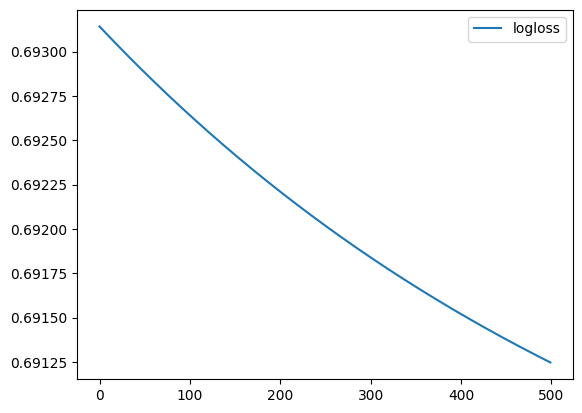

In [ ]:
settings_1 = ExperimentSettings(
    learning_rate=0.0001,
    number_epochs=500,
    batch_size=50,
    input_features=['length'],
    optimizer="batch",
    model_name = "logistic"
)



# Create model
model_1 = create_model(settings_1)

# Train model
experiment_1 = train_model(
    experiment_name="one_feature",
    model=model_1,
    dataset=training_df,
    label_name="Type",
    settings=settings_1
)

experiment_1["metrics_history"][["logloss"]].plot()